/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:28: SyntaxWarning: invalid escape sequence '\m'
  '''## Define states and controls
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:55: SyntaxWarning: invalid escape sequence '\m'
  '''We use as control the Zero Moment Point (ZMP):
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:76: SyntaxWarning: invalid escape sequence '\m'
  '''## Optimal Control Problem Parameters
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:104: SyntaxWarning: invalid escape sequence '\d'
  '''## Linear Inverted Pendulum Model Params
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:128: SyntaxWarning: invalid escape sequence '\d'
  '''## Define LIPM Dynamics
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:160: SyntaxWarning: invalid escape sequence '\s'
  '''## Cost Function
/home/enrico/Documents/inria/Teaching/introduction_to_oc/lipm.ipynb:293: S

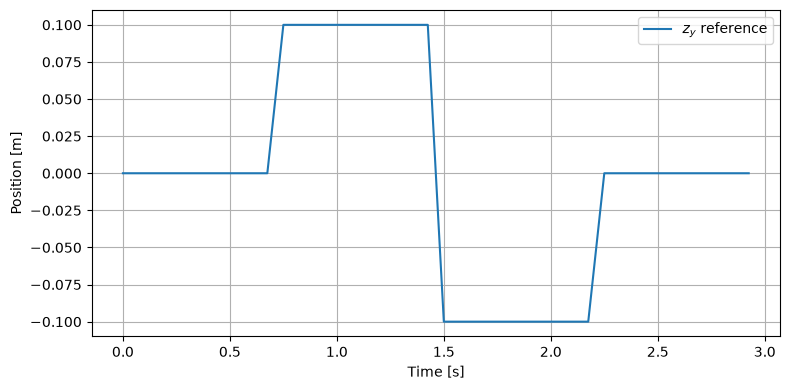

In [1]:
from IPython.display import clear_output
import numpy as np
np.set_printoptions(linewidth=10000)
import matplotlib.pyplot as plt
import time
def ttic():
    return time.time()

def ttoc(tic):
    return time.time() - tic

from importnb import Notebook

with Notebook():
    import lipm
    from zmp_ref import zmp_ref

## Riccati Factorization of KKT matrix
We will now see another optimization step, which reduces the computational complexity further based on the factorization of the KKT matrix through the Riccati recursion.

We consider the following structured optimal control problem:

$$
\begin{align}
\min\limits_{\mathbf{x},\mathbf{u}} & \frac{1}{2} \sum_{k=0}^{N-1} \left( \begin{bmatrix}\mathbf{x}_k^T & \mathbf{u}_k^T \end{bmatrix}\begin{bmatrix}\mathbf{Q}_k & \mathbf{S}^T_k\\\mathbf{S}_k & \mathbf{R}_k \end{bmatrix} \begin{bmatrix}\mathbf{x}_k \\ \mathbf{u}_k \end{bmatrix} + \begin{bmatrix}\mathbf{q}_k^T & \mathbf{r}_k^T \end{bmatrix}\begin{bmatrix}\mathbf{x}_k \\ \mathbf{u}_k \end{bmatrix}\right) + \frac{1}{2}\mathbf{x}_N^T \mathbf{Q}_N\mathbf{x}_N + \mathbf{q}_N^T\mathbf{x}_N \\ 
s.t. & \quad \mathbf{x}_{k+1} = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} + \mathbf{b}_k
\end{align}
$$


Let's consider the final part of the horizon from node $k = N-1$ to $N$, hence $\mathbf{x} = \begin{bmatrix}\mathbf{x}_k & \mathbf{x}_N\end{bmatrix}^T$ and $\mathbf{u} = \begin{bmatrix}\mathbf{u}_k\end{bmatrix}$. In this case, the problem reduces to:

$$
\begin{align}
\min\limits_{\mathbf{x},\mathbf{u}} & \frac{1}{2} \begin{bmatrix}\mathbf{x}_k^T & \mathbf{u}_k^T \end{bmatrix}\begin{bmatrix}\mathbf{Q}_k & \mathbf{S}^T_k\\\mathbf{S}_k & \mathbf{R}_k \end{bmatrix} \begin{bmatrix}\mathbf{x}_k \\ \mathbf{u}_k \end{bmatrix} + \begin{bmatrix}\mathbf{q}_k^T & \mathbf{r}_k^T \end{bmatrix}\begin{bmatrix}\mathbf{x}_k \\ \mathbf{u}_k \end{bmatrix} + \frac{1}{2}\mathbf{x}_N^T \mathbf{P}_N\mathbf{x}_N + \mathbf{p}_N^T\mathbf{x}_N \\ 
s.t. & \quad \mathbf{x}_{N} = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} + \mathbf{b}_k
\end{align}
$$
with $\mathbf{P}_N = \mathbf{Q}_N$ and $\mathbf{p}_N = \mathbf{q}_N$. 

The Lagrangian function of this problem has the following form:

$$\mathcal{L} = \frac{1}{2}\mathbf{x}_k^T\mathbf{Q}_k\mathbf{x}_k + \frac{1}{2}\mathbf{u}_k^T\mathbf{R}_k\mathbf{u}_k + \mathbf{x}_k^T\mathbf{S}_k^T\mathbf{u}_k + \mathbf{q}_k^T\mathbf{x}_k+ \mathbf{r}_k^T\mathbf{u}_k + \frac{1}{2}\mathbf{x}_N^T \mathbf{P}_N\mathbf{x}_N + \mathbf{p}_N^T\mathbf{x}_N + \boldsymbol{\pi}^T_N\left(\mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} -\mathbf{I}\mathbf{x}_N + \mathbf{b}_k \right)$$
with $\mathbf{I}$ identity matrix.

We now take derivatives of $\mathcal{L}$ w.r.t. the variables to form the KKT system:

\begin{align}
\frac{\partial\mathcal{L}}{\partial\mathbf{x}_k}& = \mathbf{Q}_k\mathbf{x}_k + \mathbf{S}_k^T\mathbf{u}_k + \mathbf{q}_k + \mathbf{A}_k^T\boldsymbol{\pi}_N = \mathbf{0} \\
\frac{\partial\mathcal{L}}{\partial\mathbf{u}_k}& = \mathbf{R}_k\mathbf{u}_k + \mathbf{S}_k\mathbf{x}_k + \mathbf{r}_k + \mathbf{B}_k^T\boldsymbol{\pi}_N = \mathbf{0} \\
\frac{\partial\mathcal{L}}{\partial\mathbf{x}_N}& = \mathbf{P}_N\mathbf{x}_N + \mathbf{p}_N - \mathbf{I}\boldsymbol{\pi}_N = \mathbf{0}\\
\frac{\partial\mathcal{L}}{\partial\boldsymbol{\pi}_N}& = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} -\mathbf{I}\mathbf{x}_N + \mathbf{b}_k = \mathbf{0} 
\end{align}

that in matrix form has the form:

$$
\begin{bmatrix}
\mathbf{Q}_k & \mathbf{S}_k^T  & \mathbf{0} & \mathbf{A}_k^T\\
\mathbf{S}_k & \mathbf{R}_k &  \mathbf{0} & \mathbf{B}_k^T \\
\mathbf{0} & \mathbf{0} &  \mathbf{P}_N & -\mathbf{I} \\
\mathbf{A}_k & \mathbf{B}_k &  -\mathbf{I} & \mathbf{0} 
\end{bmatrix}
\begin{bmatrix}
\mathbf{x}_k \\ 
\mathbf{u}_k \\
\mathbf{x}_N \\
\boldsymbol{\pi}_N
\end{bmatrix} = 
\begin{bmatrix}
-\mathbf{q}_k \\
-\mathbf{r}_k \\
-\mathbf{p}_N \\
-\mathbf{b}_k
\end{bmatrix}
$$

or in a compact notation:

$$
\begin{bmatrix}
\mathbf{H}_{k} & \mathbf{C}^T_k\\
\mathbf{C}_k & \mathbf{0} 
\end{bmatrix}
\begin{bmatrix}
\mathbf{x}_k \\ 
\mathbf{u}_k \\
\mathbf{x}_N \\
\boldsymbol{\pi}_N
\end{bmatrix} = 
\begin{bmatrix}
-\mathbf{g}_k \\
-\mathbf{b}_k
\end{bmatrix}
$$

that can be solved inverting the KKT matrix.

Alternatively, we can compute the following steps:

**1.** From $\frac{\partial\mathcal{L}}{\partial\boldsymbol{\pi}_N} = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} -\mathbf{I}\mathbf{x}_N + \mathbf{b}_k = \mathbf{0}$:

   $$\mathbf{x}_N = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} + \mathbf{b}_k$$

**2.** We substitute in $\frac{\partial\mathcal{L}}{\partial\mathbf{x}_N} = \mathbf{P}_N\mathbf{x}_N + \mathbf{p}_N - \mathbf{I}\boldsymbol{\pi}_N = \mathbf{0}$:

$$ \mathbf{P}_N\left(\mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} + \mathbf{b}_k \right) + \mathbf{p}_N - \mathbf{I}\boldsymbol{\pi}_N = \mathbf{0} $$

  -> $$ \mathbf{P}_N\mathbf{A}_k\mathbf{x}_{k} + \mathbf{P}_N\mathbf{B}_k\mathbf{u}_{k} + \mathbf{P}_N\mathbf{b}_k  + \mathbf{p}_N - \mathbf{I}\boldsymbol{\pi}_N = \mathbf{0} $$

  hence:

  $$\boldsymbol{\pi}_N = \mathbf{P}_N\mathbf{A}_k\mathbf{x}_{k} + \mathbf{P}_N\mathbf{B}_k\mathbf{u}_{k} + \mathbf{P}_N\mathbf{b}_k  + \mathbf{p}_N$$

**3.** We substitute in $\frac{\partial\mathcal{L}}{\partial\mathbf{x}_k} = \mathbf{Q}_k\mathbf{x}_k + \mathbf{S}_k^T\mathbf{u}_k + \mathbf{q}_k + \mathbf{A}_k^T\boldsymbol{\pi}_N = \mathbf{0}$:

   $$ \mathbf{Q}_k\mathbf{x}_k + \mathbf{S}_k^T\mathbf{u}_k + \mathbf{q}_k + \mathbf{A}_k^T\left( \mathbf{P}_N\mathbf{A}_k\mathbf{x}_{k} + \mathbf{P}_N\mathbf{B}_k\mathbf{u}_{k} + \mathbf{P}_N\mathbf{b}_k  + \mathbf{p}_N \right) = \mathbf{0} $$

   -> $$ \mathbf{Q}_k\mathbf{x}_k + \mathbf{S}_k^T\mathbf{u}_k + \mathbf{q}_k + \mathbf{A}_k^T\mathbf{P}_N\mathbf{A}_k\mathbf{x}_{k} + \mathbf{A}_k^T\mathbf{P}_N\mathbf{B}_k\mathbf{u}_{k} + \mathbf{A}_k^T\mathbf{P}_N\mathbf{b}_k  + \mathbf{A}_k^T\mathbf{p}_N = \mathbf{0} $$

   -> $$\left(\mathbf{Q}_k + \mathbf{A}_k^T\mathbf{P}_N\mathbf{A}_k \right)\mathbf{x}_k + \left(\mathbf{S}_k^T + \mathbf{A}_k^T\mathbf{P}_N\mathbf{B}_k \right)\mathbf{u}_k + \left[\mathbf{q}_k + \mathbf{A}_k^T\left(\mathbf{P}_N\mathbf{b}_k +   \mathbf{p}_N\right) \right] = \mathbf{0}$$

We renamed the following matrices and vectors:

   $$
    \begin{align}
       \overline{\mathbf{Q}}_k & = \mathbf{Q}_k + \mathbf{A}_k^T\mathbf{P}_N\mathbf{A}_k \\
       \overline{\mathbf{S}}_k^T & = \mathbf{S}_k^T + \mathbf{A}_k^T\mathbf{P}_N\mathbf{B}_k \\
       \overline{\mathbf{q}}_k & = \mathbf{q}_k + \mathbf{A}_k^T\left(\mathbf{P}_N\mathbf{b}_k +   \mathbf{p}_N\right)    
    \end{align}
   $$
   to obtain:

   $$ \overline{\mathbf{Q}}_k\mathbf{x}_k + \overline{\mathbf{S}}_k^T\mathbf{u}_k + \overline{\mathbf{q}}_k = \mathbf{0}  $$

**4.** We substitute the result of step **2.** in $\frac{\partial\mathcal{L}}{\partial\mathbf{u}_k} = \mathbf{R}_k\mathbf{u}_k + \mathbf{S}_k\mathbf{x}_k + \mathbf{r}_k + \mathbf{B}_k^T\boldsymbol{\pi}_N = \mathbf{0}$. Following the same steps, we arrive at the form:

$$\left(\mathbf{R}_k + \mathbf{B}_k^T\mathbf{P}_N\mathbf{B}_k \right)\mathbf{u}_k + \left(\mathbf{S}_k + \mathbf{B}_k^T\mathbf{P}_N\mathbf{A}_k \right)\mathbf{x}_k + \left[\mathbf{r}_k + \mathbf{B}_k^T\left(\mathbf{P}_N\mathbf{b}_k + \mathbf{p}_N \right) \right] = \mathbf{0} $$

We renamed the following matrices and vectors:

   $$
    \begin{align}
       \overline{\mathbf{R}}_k & = \mathbf{R}_k + \mathbf{B}_k^T\mathbf{P}_N\mathbf{B}_k \\
       \overline{\mathbf{S}}_k & = \mathbf{S}_k + \mathbf{B}_k^T\mathbf{P}_N\mathbf{A}_k \\
       \overline{\mathbf{r}}_k & = \mathbf{r}_k + \mathbf{B}_k^T\left(\mathbf{P}_N\mathbf{b}_k +   \mathbf{p}_N\right)    
    \end{align}
   $$
   to obtain:

   $$ \overline{\mathbf{S}}_k\mathbf{x}_k + \overline{\mathbf{R}}_k^T\mathbf{u}_k + \overline{\mathbf{r}}_k = \mathbf{0}  $$


The results from steps **3.** and **4.** can be combined in matrix form:

$$
\begin{bmatrix}
\overline{\mathbf{Q}}_k & \overline{\mathbf{S}}_k^T \\
\overline{\mathbf{S}}_k & \overline{\mathbf{R}}_k
\end{bmatrix}
\begin{bmatrix}
\mathbf{x}_k \\
\mathbf{u}_k
\end{bmatrix} = 
\begin{bmatrix}
-\overline{\mathbf{q}}_k \\
-\overline{\mathbf{r}}_k
\end{bmatrix}
$$
which corresponds to a linear system in the solely $\mathbf{x}_k$ and $\mathbf{u}_k$ variables.

**5.** $\text{\textcolor{red}{Assuming fixed state}}$, from the second row we can compute the control $\mathbf{u}_k$ in function of the state $\mathbf{x}_k$:

   $$\mathbf{u}_k = -\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k - \overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\mathbf{x}_k$$

  We renamed the matrix and the vector:
  $$
    \begin{align}
        \mathbf{K}_k &= -\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\\
        \mathbf{k}_k &= -\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k
    \end{align}
  $$

  hence:

  $$ \mathbf{u}_k = {\mathbf{K}}_k\mathbf{x}_k + \mathbf{k}_k $$

If we substitute the expression $\mathbf{u}_k = -\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k - \overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\mathbf{x}_k$ in the first row we can compute the following:

  $$\overline{\mathbf{Q}}_k\mathbf{x}_k + \overline{\mathbf{S}}_k^T \left(-\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k - \overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\mathbf{x}_k \right) = -\overline{\mathbf{q}}_k $$

  -> $$\left(\overline{\mathbf{Q}}_k - \overline{\mathbf{S}}_k^T\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\right)\mathbf{x}_k = -\overline{\mathbf{q}}_k + \overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k $$ 

    We renamed the matrix and the vector:
  $$
    \begin{align}
        \overline{\mathbf{P}}_k &= \overline{\mathbf{Q}}_k - \overline{\mathbf{S}}_k^T\overline{\mathbf{R}}_k^{-1}\overline{\mathbf{S}}_k\\
        \overline{\mathbf{p}}_k &= \overline{\mathbf{q}}_k - \overline{\mathbf{R}}_k^{-1}\overline{\mathbf{r}}_k
    \end{align}
  $$


### Recursion
At iteration $k$, we consider the triplet $\mathbf{x}_k$, $\mathbf{u}_k$, and $\mathbf{x}_{k+1}$.

  1. In the *backward pass* we compute $\overline{\mathbf{P}}_k$, $\overline{\mathbf{p}}_k$, $\mathbf{K}_k$, and $\mathbf{k}_k$, inputting $\overline{\mathbf{P}}_{k+1}$, $\overline{\mathbf{p}}_{k+1}$ computed at the previous iteration.

  2. The *backward pass* is initialized with $\mathbf{P}_N = \mathbf{Q}_N$ and $\mathbf{p}_N = \mathbf{q}_N$ and computes backard until node $0$ all the matrices $\mathbf{K}$ and vectors $\mathbf{k}$.

  3. In the *forward pass*, starting from node 0 to node N, we compute the control $\mathbf{u}_k = \mathbf{K}_k\mathbf{x}_k + \mathbf{k}_k$ and the next state $\mathbf{x}_{k+1} = \mathbf{A}_k\mathbf{x}_{k} + \mathbf{B}_k\mathbf{u}_{k} + \mathbf{b}_k$. If not given, we compute the initial state as $\mathbf{x}_0 = -\overline{\mathbf{P}}_0^{-1}\overline{\mathbf{p}}_0$.

In [2]:
def QRS(Q, S, R, A, B, P):
    Q_ = Q + A.T@P@A
    R_ = R + B.T@P@B
    S_ = S + B.T@P@A
    return Q_, R_, S_

def qr(q, r, A, B, b, P, p):
    l = P@b + p
    q_ = q + A.T@l
    r_ = r + B.T@l
    return q_, r_

def riccati_backward(Q, S, R, q, r, P, p, A, B, b):
    Q_, R_, S_ = QRS(Q, S, R, A, B, P)
    q_, r_ = qr(q, r, A, B, b, P, p)

    R_i = np.linalg.pinv(R_)
    P_ = Q_ - S_.T@R_i@S_
    p_ = q_ - S_.T@R_i@r_

    K = -R_i @ S_
    k = -R_i @ r_

    return P_, p_, K, k

def riccati_forward(x0, K, k, A, B, b):
    u = K@x0 + k
    x = A@x0 + B@u + b

    return x,u

We now apply the Riccati recursion to our OCP.

## Trajectory Optimization

We first define the running cost matrices and vectors, separating the states and the controls, respectively $\mathbf{Q}_k$, $\mathbf{R}_k$, and the final cost $\mathbf{Q}_{fin}$ (and respective gradients). 

The same reasoning applies to the matrices defining the dynamics, $\mathbf{A}_k$ and $\mathbf{B}_k$. 

In [3]:
from collections import deque

Qk = np.zeros((lipm.nx,lipm.nx))
Qk[lipm.nr:lipm.nr+lipm.nr, lipm.nr:lipm.nr+lipm.nr] = lipm.Q*np.eye(lipm.nrdot)
Rk = np.zeros((lipm.nu,lipm.nu))
Rk[0:lipm.nu, 0:lipm.nu] = lipm.R*np.eye(lipm.nu)

Qf = np.zeros((lipm.nx,lipm.nx))
Qf[lipm.nr:lipm.nr+lipm.nr, lipm.nr:lipm.nr+lipm.nr] = lipm.Qfin*np.eye(lipm.nrdot)

#print(Qk)
#print(Rk)
#print(Qf)

# Assign reference for zmp
for j in range(lipm.ns):
         lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_ref(lipm.ns)[:, j].flatten())

A, B = lipm.dynamics(lipm.w)
E = lipm.Euler(A, B, lipm.dt)
Ak = E[:,0:lipm.nx]
Bk = E[:,lipm.nx:lipm.nx+lipm.nu]

#print(Ak)
#print(Bk)

solved in: 0.009477615356445312 seconds


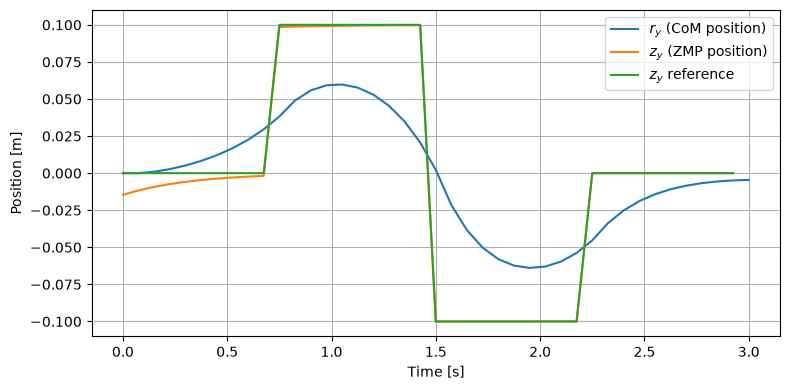

In [4]:
x = []
u = []
for i in range(0, lipm.ns):
    x.append(np.zeros((lipm.nx, 1)))
    u.append(np.zeros((lipm.nu, 1)))
x.append(np.ones((lipm.nx, 1)))

P = Qf
p = np.zeros((lipm.nx,1))
K = deque()
d = deque()

t_backward = 0
for k in range(lipm.ns-1 ,-1, -1):
    qk = lipm.grad[k * (lipm.nx + lipm.nu):k * (lipm.nx + lipm.nu) + lipm.nx]
    rk = lipm.grad[k * (lipm.nx + lipm.nu) + lipm.nx:k * (lipm.nx + lipm.nu) + lipm.nx + lipm.nu]
    tic = ttic()
    P, p, Kk, dk = riccati_backward(Qk, np.zeros((lipm.nu,lipm.nx)), Rk, qk, rk, P, p, Ak, Bk, np.zeros((lipm.nx,1)))
    t_backward += ttoc(tic)
    K.appendleft(Kk)
    d.appendleft(dk)
    
t_forward = 0
for k in range(0, lipm.ns):
    if k == 0:
        x[0] = np.zeros((lipm.nx,1))   
    tic = ttic()
    x[k+1], u[k] = riccati_forward(x[k], K[k], d[k], Ak, Bk, np.zeros((lipm.nx,1)))
    t_forward += ttoc(tic)

print(f"solved in: {t_backward + t_forward} seconds")

# Extract r and rdot
r = np.zeros((2, lipm.ns + 1))
rdot = np.zeros((2, lipm.ns + 1))
uu = np.zeros((2, lipm.ns))
for i in range(lipm.ns + 1):
    r[:, i] = np.array(x[i][0:lipm.nr]).flatten()
    rdot[:, i] = np.array(x[i][lipm.nr:lipm.nx]).flatten()
    if i < lipm.ns:
        uu[:, i] = np.array(u[i][:]).flatten()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(np.arange(lipm.ns + 1) * lipm.dt, r[1, :], label='$r_y$ (CoM position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, uu[1,:], label='$z_y$ (ZMP position)')
plt.plot(np.arange(lipm.ns) * lipm.dt, zmp_ref(lipm.ns)[1,:], label='$z_y$ reference')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## MPC

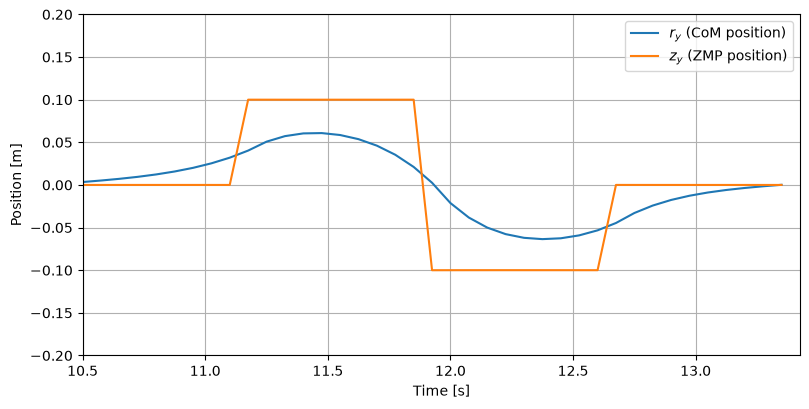

Average solution time is: 0.0028269901871681214 seconds


In [5]:
# Simulation parameters
T = 4 * lipm.ns # Simulation time

# Zero all references
for i in range(lipm.ns):
    lipm.grad[i * (lipm.nx + lipm.nu):(i + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, np.zeros((2,1)).flatten())

x = np.zeros((lipm.nx, lipm.ns)) 
u = np.zeros((lipm.nu, lipm.ns)) 

x0 = np.zeros((lipm.nx, 1))
zmp_r = zmp_ref(lipm.ns)  # Future ZMP references
zmp_d = np.zeros(zmp_r.shape)

# --- Prepare Plot ---
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot(np.arange(lipm.ns) * lipm.dt, zmp_d[1, :], 'b-', label='$z_d$ (zmp desired)')
ax.set_xlim(0, lipm.ns * lipm.dt)
ax.set_xlabel('Time [s]')
ax.set_ylabel('ZMP [m]')
ax.set_title('ZMP Desired Over Time')
ax.legend()
fig.tight_layout()

scroll = 0
# --- Main Loop ---
xc = []
uc = []
for i in range(0, lipm.ns):
    xc.append(np.zeros((lipm.nx, 1)))
    uc.append(np.zeros((lipm.nu, 1)))
xc.append(lipm.np.ones((lipm.nx, 1)))
t = 0
for i in range(T):
    x[:, i%lipm.ns] = x0.flatten()

    # Shift reference
    for j in range(1, lipm.ns):
        zmp_d[:, j-1] = zmp_d[:, j]
    zmp_d[:, lipm.ns-1] = zmp_r[:, i % lipm.ns]
    
    # Compute gradient
    for j in range(lipm.ns):
        lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_d[:, j])

    # Solve the QP
    P = Qf
    p = np.zeros((lipm.nx,1))
    K = deque()
    d = deque()


    t_backward = 0

    for k in range(lipm.ns-1 ,-1, -1):
        qk = lipm.grad[k * (lipm.nx + lipm.nu):k * (lipm.nx + lipm.nu) + lipm.nx]
        rk = lipm.grad[k * (lipm.nx + lipm.nu) + lipm.nx:k * (lipm.nx + lipm.nu) + lipm.nx + lipm.nu]     
        tic = ttic()
        P, p, Kk, dk = riccati_backward(Qk, np.zeros((lipm.nu,lipm.nx)), Rk, qk, rk, P, p, Ak, Bk, np.zeros((lipm.nx,1)))
        t_backward += ttoc(tic)
        K.appendleft(Kk)
        d.appendleft(dk)
    
    t_forward = 0
    for k in range(0, lipm.ns):
        if k == 0:
            xc[0] = x0
        tic = ttic()
        xc[k+1], uc[k] = riccati_forward(xc[k], K[k], d[k], Ak, Bk, np.zeros((lipm.nx,1)))
        t_forward += ttoc(tic)

    t += t_backward + t_forward

    u0 = uc[0]
    x1 = x0 + lipm.dt * (A @ x0 + B @ u0)
    x0 = x1

    u[:, i%lipm.ns] = u0.flatten()

    # --- Update Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    if i >= lipm.ns/2:
        scroll = scroll + 1
    
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, x[1, 0:i%lipm.ns], label='$r_y$ (CoM position)')
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, u[1, 0:i%lipm.ns], label='$z_y$ (ZMP position)')
    plt.ylim(-0.2, 0.2)
    plt.xlim(0 + scroll*lipm.dt, (i%lipm.ns+scroll)*lipm.dt)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xlabel('Time [s]')
    plt.ylabel('Position [m]')
    plt.show()

plt.ioff()
plt.show()

print(f"Average solution time is: {t/T} seconds")

#### Some Optimization
We can epxloit the fact that the system is LTI, hence we do not need to compute the Riccati gains at each iteration.

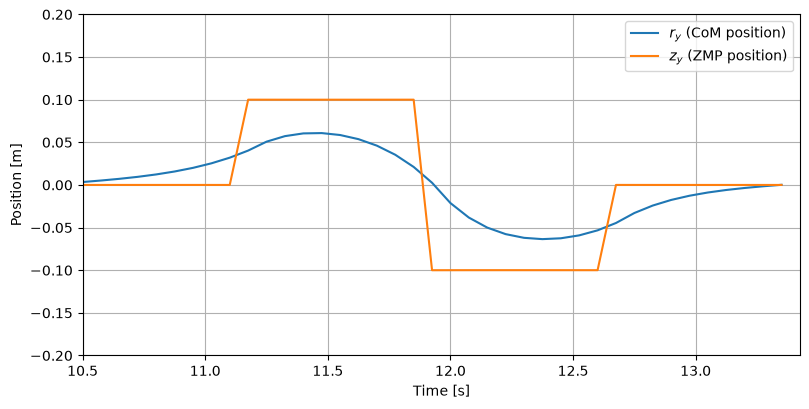

Average solution time is: 0.0009157434105873108 seconds


In [9]:
# Simulation parameters
T = 4 * lipm.ns # Simulation time

# Zero all references
for i in range(lipm.ns):
    lipm.grad[i * (lipm.nx + lipm.nu):(i + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, np.zeros((2,1)).flatten())

x = np.zeros((lipm.nx, lipm.ns)) 
u = np.zeros((lipm.nu, lipm.ns)) 

x0 = np.zeros((lipm.nx, 1))
zmp_r = zmp_ref(lipm.ns)  # Future ZMP references
zmp_d = np.zeros(zmp_r.shape)

# --- Prepare Plot ---
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))
line, = ax.plot(np.arange(lipm.ns) * lipm.dt, zmp_d[1, :], 'b-', label='$z_d$ (zmp desired)')
ax.set_xlim(0, lipm.ns * lipm.dt)
ax.set_xlabel('Time [s]')
ax.set_ylabel('ZMP [m]')
ax.set_title('ZMP Desired Over Time')
ax.legend()
fig.tight_layout()

scroll = 0
# --- Main Loop ---
xc = []
uc = []
for i in range(0, lipm.ns):
    xc.append(np.zeros((lipm.nx, 1)))
    uc.append(np.zeros((lipm.nu, 1)))
xc.append(lipm.np.ones((lipm.nx, 1)))
t = 0

# PRECOMPUTE RICCATI GAINS
P = Qf
K = deque()
Ps = deque()
Ps.appendleft(Qf)
Ris = deque()
Ss = deque()
for k in range(lipm.ns-1 ,-1, -1):
        Q_, R_, S_ = QRS(Qk, np.zeros((lipm.nu,lipm.nx)), Rk, Ak, Bk, P)

        R_i = np.linalg.pinv(R_)
        P = Q_ - S_.T@R_i@S_    
        Kk = -R_i @ S_
    
        K.appendleft(Kk)
        Ps.appendleft(P)
        Ris.appendleft(R_i)
        Ss.appendleft(S_)
        
for i in range(T):
    x[:, i%lipm.ns] = x0.flatten()

    # Shift reference
    for j in range(1, lipm.ns):
        zmp_d[:, j-1] = zmp_d[:, j]
    zmp_d[:, lipm.ns-1] = zmp_r[:, i % lipm.ns]
    
    # Compute gradient
    for j in range(lipm.ns):
        lipm.grad[j * (lipm.nx + lipm.nu):(j + 1) * (lipm.nx + lipm.nu)] = lipm.running_cost_gradient(lipm.R, zmp_d[:, j])

    # Solve the QP
    
    p = np.zeros((lipm.nx,1))
    d = deque()
    t_backward = 0
    for k in range(lipm.ns-1 ,-1, -1):
        qk = lipm.grad[k * (lipm.nx + lipm.nu):k * (lipm.nx + lipm.nu) + lipm.nx]
        rk = lipm.grad[k * (lipm.nx + lipm.nu) + lipm.nx:k * (lipm.nx + lipm.nu) + lipm.nx + lipm.nu]     
        tic = ttic()

        q_, r_ = qr(qk, rk, Ak, Bk, np.zeros((lipm.nx,1)), Ps[k], p)
        dk = -Ris[k] @ r_
        p = q_ - Ss[k].T@Ris[k]@r_
        
        t_backward += ttoc(tic)
        d.appendleft(dk)
    
    t_forward = 0
    for k in range(0, lipm.ns):
        if k == 0:
            xc[0] = x0
        tic = ttic()
        xc[k+1], uc[k] = riccati_forward(xc[k], K[k], d[k], Ak, Bk, np.zeros((lipm.nx,1)))
        t_forward += ttoc(tic)

    t += t_backward + t_forward

    u0 = uc[0]
    x1 = x0 + lipm.dt * (A @ x0 + B @ u0)
    x0 = x1

    u[:, i%lipm.ns] = u0.flatten()

    # --- Update Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    if i >= lipm.ns/2:
        scroll = scroll + 1
    
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, x[1, 0:i%lipm.ns], label='$r_y$ (CoM position)')
    plt.plot(np.arange(scroll, i%lipm.ns+scroll)*lipm.dt, u[1, 0:i%lipm.ns], label='$z_y$ (ZMP position)')
    plt.ylim(-0.2, 0.2)
    plt.xlim(0 + scroll*lipm.dt, (i%lipm.ns+scroll)*lipm.dt)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xlabel('Time [s]')
    plt.ylabel('Position [m]')
    plt.show()

plt.ioff()
plt.show()

print(f"Average solution time is: {t/T} seconds")